# Seurat (R) tutorial
### How to run Ouroboros on a Seurat (R) object

Ouroboros is a python package, so running it on a Seurat object requires saving your raw counts as a CSV file and running the command-line implementation of Ouroboros on the saved CSV. The ouroboros output can then be loaded into back into R.


Dependencies:
- Seurat
- SeuratObject
- Matrix
- Zellconverter 
- SingleCellExperiment


In [ ]:
suppressPackageStartupMessages({
  library(Seurat)
  library(SeuratObject)
  library(Matrix)
  library(zellkonverter)
  library(SingleCellExperiment)
  library(SeuratData)
})

We'll demonstrate Ouroboros using **pbmc3k**, a standard dataset of 2,700 PBMCs
(~13,700 genes) that ships as raw counts. We subset it to 100 cells to remove computational time and written object size. 

In [10]:
InstallData("pbmc3k")
data("pbmc3k")

pbmc3k   # ~2700 cells x ~13714 genes, raw counts in the RNA assay

Installing package into ‘/projects/pangen/analysis/hmac/applications/miniconda3/lib/R/library’
(as ‘lib’ is unspecified)



In [12]:
set.seed(330)
cells <- colnames(GetAssayData(pbmc3k, assay = "RNA", layer = "counts"))
pbmc100 <- pbmc3k[, sample(cells, 100)]

Next write the raw counts as a Scanpy h5ad object to run ouroboros on. 
    p.s. this tends to take a long time (~ 15 minutes)

In [17]:
# Seurat -> SingleCellExperiment
sce <- as.SingleCellExperiment(pbmc100)

# confirm a raw-counts assay is present
assayNames(sce)          # expect "counts" (and usually "logcounts")

# write .h5ad with RAW counts in .X
writeH5AD(sce, "R_example_output/pbmc_small.h5ad", X_name = "counts")

[1] "counts"    "logcounts"

There is still some formatting of that h5ad that needs to be done so Ouroboros will recognize it. Run this in a terminal (replace the h5ad path with your own):

```bash
conda activate ouroboros_env

# go to your output dir
cd R_example_output
```

```bash
python - <<'PY'
import h5py, numpy as np, anndata as ad
path = "pbmc_small.h5ad"
vlen = h5py.special_dtype(vlen=str)
with h5py.File(path, "r+") as f:
    if "layers/raw_counts" not in f:
        f.copy("X", "layers/raw_counts")

    # strip modern 'dict' tags (already done, but harmless to repeat)
    def fix_dict(name, obj):
        if isinstance(obj, h5py.Group):
            et = obj.attrs.get("encoding-type")
            et = et.decode() if isinstance(et, (bytes, bytearray)) else et
            if et == "dict":
                del obj.attrs["encoding-type"]; obj.attrs.pop("encoding-version", None)
    f.visititems(fix_dict)

    # flatten obs/var to index-only: drop categorical/group columns the old reader can't parse
    for key in ("obs", "var"):
        if key not in f: continue
        g = f[key]
        idx = g.attrs.get("_index", "_index")
        idx = idx.decode() if isinstance(idx, (bytes, bytearray)) else idx
        for col in list(g.keys()):
            if col != idx:
                del g[col]
        g.attrs.create("column-order", np.array([], dtype=vlen))
PY
```


Double check it worked with this: 
```bash
python - <<'PY'
import anndata as ad
a = ad.read_h5ad("pbmc_small.h5ad")
print("OK:", a.shape, "| genes:", list(a.var_names[:3]), "| raw_counts:", "raw_counts" in a.layers)
PY
```

Then run Ouroboros on test object on command line

Call:
```bash

ouroboros \
    --data pbmc_small.h5ad \
    --data_type h5ad \
    --outdir .
```

## Read Ouroboros output into Seurat object

In [ ]:
emb <- read.csv(
  "R_example_output/ouroboros_embeddings_pseudotimes.csv",
  row.names = 1,          # first column is the cell_id index pandas wrote
  check.names = FALSE     # keep column names like dim1/dim3 exactly as-is
)

# sanity check: do the IDs line up with the Seurat object?
head(rownames(emb))
head(colnames(pbmc100))
mean(rownames(emb) %in% colnames(pbmc100))   # want this to be 1 

# add all Ouroboros columns to the cell metadata
pbmc100 <- AddMetaData(pbmc100, metadata = emb)

head(pbmc100@meta.data)

[1] "AAACCGTGCTTCCG" "AAAGAGACGCGAGA" "AAGATTACCCGTTC" "AAGCAAGAGGTGTT"
[5] "AAGTTCCTCATTCT" "AATGTTGATCTACT"

[1] "AAACCGTGCTTCCG" "AAAGAGACGCGAGA" "AAGATTACCCGTTC" "AAGCAAGAGGTGTT"
[5] "AAGTTCCTCATTCT" "AATGTTGATCTACT"

[1] 1

,orig.ident,nCount_RNA,nFeature_RNA,seurat_annotations,RNA_snn_res.0.5,seurat_clusters,dim1,dim2,dim3,KNN_phase,cell_cycle_pseudotime,south,dormancy_depth,G0_classification
,<fct>,<dbl>,<int>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>
AAACCGTGCTTCCG,pbmc3k,2639,960,CD14+ Mono,1,1,-0.2796167,0.9579706,-0.06408316,G0,NA,True,-0.5078842,quiescence
AAAGAGACGCGAGA,pbmc3k,3033,1058,CD14+ Mono,1,1,-0.7858221,0.5954063,0.16725660,G0,NA,True,-0.8482282,senescence
AAGATTACCCGTTC,pbmc3k,2762,928,CD14+ Mono,1,1,-0.6899688,0.5372884,0.48504025,G0,NA,True,-0.8712022,senescence
AAGCAAGAGGTGTT,pbmc3k,1684,857,NK,0,0,-0.5400499,-0.5703587,0.61889990,G2M,NA,True,-0.4522001,quiescence
AAGTTCCTCATTCT,pbmc3k,2334,862,FCGR3A+ Mono,1,1,-0.0417582,0.4772747,0.87776140,G0,NA,True,-0.4849494,quiescence
AATGTTGATCTACT,pbmc3k,2672,960,Memory CD4 T,0,0,-0.6850837,0.7279406,-0.02761939,G0,NA,True,-0.7152675,senescence


Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -2.019”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 0.32006”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  0”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“There are other near singularities as well. 0.031008”
Centering and scaling data matrix

PC_ 1 
Positive:  CST3, AIF1, LST1, FCER1G, TYROBP, CFD, FTL, NPC2, FTH1, S100A11 
	   LGALS1, FCN1, LYZ, CTSS, PSAP, S100A9, SERPINA1, CD68, RP11-290F20.3, SAT1 
	   BRI3, TYMP, SPI1, MNDA, COTL1, IFITM3, IFI30, MS4A7, FGR, OAZ1 
Negative:  MALAT1, RPS6, RPL13, LTB, ISG20, CD3E, CD7, CXCR4, RPLP0, CTSW 
	   LYAR, FKBP11, CCL5, CCR7, NKG7, GZMA, UBXN4, NOSIP, RARRES3, TRABD2A 
	   TRAT1, DENND2D, RPL10, S1PR4, HSPE1, BBC3, RPS14, PBXIP1, AQP3, TCF7 
PC

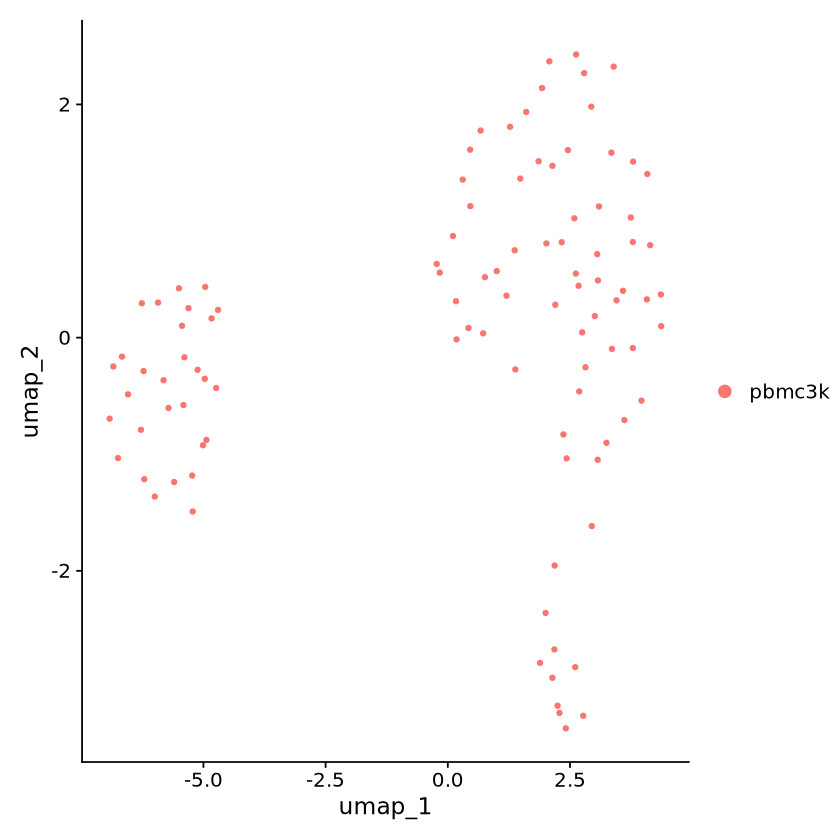

In [ ]:
pbmc100 <- NormalizeData(pbmc100)
pbmc100 <- FindVariableFeatures(pbmc100)
pbmc100 <- ScaleData(pbmc100)
pbmc100 <- RunPCA(pbmc100, npcs = 30)
pbmc100 <- RunUMAP(pbmc100, dims = 1:20, n.neighbors = 15)

DimPlot(pbmc100, reduction = "umap")

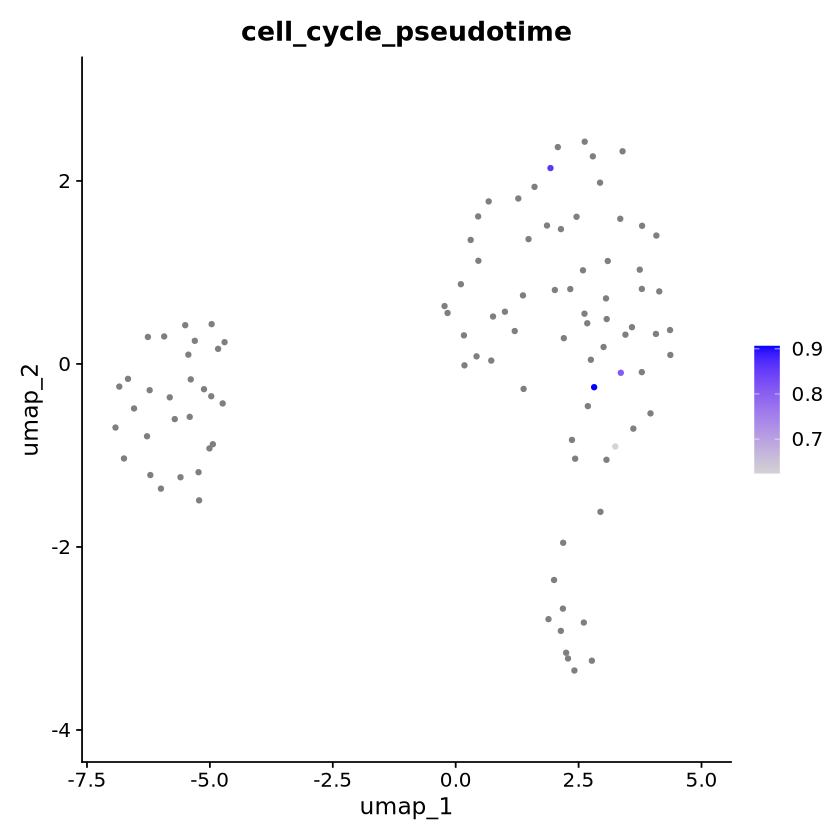

In [19]:
# Can colour UMAPs by Ouroboros variables
FeaturePlot(pbmc100, features = "cell_cycle_pseudotime")